# 06 — ML (2/3) : Classification (club_member_status) & Régression (total_spend)

*Notebook*

> **Dépendances :** Nécessite la même table de features clients que le notebook 05 (section 17.1 de préparation des données).


## 0. Reprise depuis le notebook précédent

Nécessite `nb05_ml_prep.pkl`, exporté par **05_ML_ReductionDim_Clustering_Rapide.ipynb**.

In [1]:
import os, pickle, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    with open(os.path.join(INTERMEDIATE_DIR, "nb05_ml_prep.pkl"), "rb") as f:
        _prep = pickle.load(f)
    ml_sample = _prep["ml_sample"]
    X_behavior_scaled = _prep["X_behavior_scaled"]
    scaler = _prep["scaler"]
    behavior_features = _prep["behavior_features"]
    print(f"Repris : ml_sample {ml_sample.shape}, X_behavior_scaled {X_behavior_scaled.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(
        "nb05_ml_prep.pkl introuvable. Exécute 05_ML_ReductionDim_Clustering_Rapide.ipynb avant ce notebook."
    ) from e


Mounted at /content/drive
Repris : ml_sample (1362281, 17), X_behavior_scaled (1362281, 7)


### 17.5 Classification supervisée — prédire le statut club (`club_member_status`)

**Objectif :** prédire si un client est `ACTIVE`, `PRE-CREATE` ou `LEFT CLUB` à partir de son seul
comportement d'achat (sans utiliser le statut lui-même, évidemment). Cinq modèles sont comparés :
Régression Logistique, k-plus-proches-voisins (KNN), SVM, Arbre de décision, Random Forest.

> ⚠️ Les classes sont très déséquilibrées (`ACTIVE` ≈ 93%, `LEFT CLUB` < 0,1%) : l'**accuracy**
> seule serait trompeuse (un modèle qui prédit toujours `ACTIVE` aurait déjà 93% d'accuracy sans
> rien apprendre). On utilise donc aussi le **F1-score macro** (moyenne non pondérée du F1 par
> classe), plus sévère et plus honnête ici.


Le **F1-score** est une métrique utilisée en classification qui combine la **précision (Precision)** et le **rappel (Recall)** grâce à leur moyenne harmonique.

La formule est :
$$
\boxed{ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} }
$$
avec :

**1) Précision (Precision)**

Elle mesure la proportion des prédictions positives qui sont réellement positives :
$$
\boxed{ \text{Precision} = \frac{TP}{TP + FP} }
$$

- **TP (True Positive) :** vrais positifs (positifs correctement détectés)
- **FP (False Positive) :** faux positifs (prédits positifs mais réellement négatifs)

**2) Rappel (Recall) ou Sensibilité**

Il mesure la proportion des vrais positifs qui ont été détectés :

$$
\boxed{ \text{Recall} = \frac{TP}{TP + FN} }
$$

- **FN (False Negative) :** faux négatifs (positifs manqués)

**Formule développée directement avec la matrice de confusion :**
$$
\boxed{ F1 = \frac{2TP}{2TP + FP + FN} }
$$

**Interprétation :**
- F1 proche de 1 → excellent équilibre entre précision et rappel.
- F1 proche de 0 → mauvais modèle.

> Il est particulièrement utile lorsque les classes sont déséquilibrées (ex : fraude, maladie rare, détection de spam), car l'accuracy peut être trompeuse.

| Critère                  | F1-macro                                  | F1-pondéré                                       |
| ------------------------ | ----------------------------------------- | ------------------------------------------------ |
| Calcul                   | Moyenne simple des classes                | Moyenne pondérée par le nombre d'exemples        |
| Poids des classes        | Toutes les classes ont le même poids      | Les grandes classes ont plus d'influence         |
| Sensible au déséquilibre | ✅ Oui                                     | ❌ Moins                                          |
| Utilisation              | Quand toutes les classes sont importantes | Quand la distribution réelle doit être respectée |
| Objectif                 | Mesurer l'équité entre classes            | Mesurer la performance globale                   |


**1) F1-macro**

Le F1-macro calcule le F1-score de chaque classe séparément, puis fait une moyenne simple :

$$
\boxed{ F1_{macro} = \frac{F1_A + F1_B + F1_C}{3} }
$$

Chaque classe a le même poids, peu importe son nombre d'exemples.

**2) F1-pondéré (Weighted F1-score)**

Le F1 pondéré calcule une moyenne des F1-scores, mais chaque classe est pondérée par son nombre d'exemples :

$$
\boxed{ F1_{weighted} = \frac{n_A F1_A + n_B F1_B + n_C F1_C}{n_A + n_B + n_C} }
$$

où :
- $n_A, n_B, n_C$ = nombre d'observations dans chaque classe.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_clf = ml_sample["club_member_status"]
Xtr, Xte, ytr, yte = train_test_split(
    X_behavior_scaled, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

# SVM et KNN ont une complexité (temps ET mémoire) qui explose au-delà de quelques dizaines de
# milliers de lignes, quelle que soit la RAM disponible : on les entraîne donc sur un
# sous-échantillon borné, même en mode FULL_SCALE.
SLOW_MODEL_CAP = 50_000
if len(Xtr) > SLOW_MODEL_CAP:
    _cap_idx = np.random.RandomState(42).choice(len(Xtr), SLOW_MODEL_CAP, replace=False)
    Xtr_slow, ytr_slow = Xtr[_cap_idx], ytr.iloc[_cap_idx]
else:
    Xtr_slow, ytr_slow = Xtr, ytr

classifiers_fast = {
    "Régression Logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Arbre de décision": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
}
classifiers_slow = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced"),
}

clf_results = []
fitted_classifiers = {}

for name, clf in classifiers_fast.items():
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    clf_results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(yte, pred),
        "F1-macro": f1_score(yte, pred, average="macro"),
        "F1-pondéré": f1_score(yte, pred, average="weighted"),
    })
    fitted_classifiers[name] = (clf, pred)

for name, clf in classifiers_slow.items():
    clf.fit(Xtr_slow, ytr_slow)
    pred = clf.predict(Xte)
    clf_results.append({
        "Modèle": name + (" [sous-échantillon]" if len(Xtr) > SLOW_MODEL_CAP else ""),
        "Accuracy": accuracy_score(yte, pred),
        "F1-macro": f1_score(yte, pred, average="macro"),
        "F1-pondéré": f1_score(yte, pred, average="weighted"),
    })
    fitted_classifiers[name] = (clf, pred)

clf_results_df = pd.DataFrame(clf_results).sort_values("F1-macro", ascending=False).reset_index(drop=True)
clf_results_df

import gc as _gc; _gc.collect()

71

**1) Explication des algorithmes**

| Modèle                                | Principe de fonctionnement                                                                                                                                                                                                             | Avantages                                                                                                                    | Limites                                                                                                                          |
| ------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **Arbre de décision (Decision Tree)** | Construit une structure en forme d'arbre où chaque nœud applique une règle de décision sur une variable afin de séparer les classes. Les divisions sont choisies pour maximiser la séparation entre les groupes (ex : Gini, Entropie). | - Facile à interpréter <br>- Gère les relations non linéaires <br>- Peu de préparation des données                           | - Risque de surapprentissage (overfitting) <br>- Sensible aux petites variations des données                                     |
| **KNN (K-Nearest Neighbors)**         | Pour classer un nouvel exemple, l'algorithme cherche les **K points les plus proches** dans l'espace des données et attribue la classe majoritaire parmi ces voisins.                                                                  | - Simple à comprendre <br>- Pas de phase d'entraînement complexe <br>- Fonctionne bien avec des données bien séparées        | - Coûteux sur de grands volumes de données <br>- Sensible au choix de K et à l'échelle des variables                             |
| **Random Forest**                     | C'est un ensemble de plusieurs arbres de décision (**ensemble learning**). Chaque arbre est entraîné sur un sous-ensemble différent des données et des variables. La décision finale correspond au vote majoritaire des arbres.        | - Réduit le surapprentissage par rapport à un arbre seul <br>- Bonne performance générale <br>- Gère les relations complexes | - Moins interprétable qu'un arbre simple <br>- Plus coûteux en calcul                                                            |
| **SVM (RBF Kernel)**                  | Le SVM cherche un hyperplan qui sépare les classes avec la plus grande marge possible. Le noyau **RBF (Radial Basis Function)** permet de créer des frontières non linéaires en transformant implicitement l'espace des données.       | - Très performant avec des données complexes et peu nombreuses <br>- Bonne généralisation                                    | - Sensible aux paramètres (`C`, `gamma`) <br>- Moins efficace avec beaucoup de données <br>- Nécessite souvent une normalisation |
| **Régression Logistique**             | Modèle statistique qui calcule la probabilité qu'un exemple appartienne à une classe grâce à une combinaison linéaire des variables. Malgré son nom, c'est un algorithme de classification.                                            | - Rapide et simple <br>- Facile à interpréter <br>- Bonne baseline pour comparer les modèles                                 | - Suppose une relation linéaire entre les variables et la cible <br>- Moins performant sur des relations complexes               |


**2) Interprétation des résultats**

| Modèle                    |   Accuracy |   F1-macro | F1-pondéré | Interprétation                                                                                                                                                                                                                                          |
| ------------------------- | ---------: | ---------: | ---------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Random Forest**         | **0.9294** |     0.3391 | **0.9012** | Meilleur modèle selon l'accuracy et le F1 pondéré. Il prédit correctement la majorité des observations et gère bien la distribution globale des classes. Cependant, son F1-macro faible indique qu'il performe moins bien sur les classes minoritaires. |
| **KNN**                   |     0.9246 |     0.3434 |     0.8998 | Très bonne performance globale proche de Random Forest. Le F1-macro légèrement supérieur montre un équilibre un peu meilleur entre les classes, mais il reste limité sur les classes rares.                                                             |
| **Arbre de décision**     |     0.8862 | **0.3627** |     0.8851 | L'accuracy est inférieure aux modèles d'ensemble, mais il obtient le meilleur F1-macro. Cela signifie qu'il traite relativement mieux les classes minoritaires, même si ses performances globales sont plus faibles.                                    |
| **SVM (RBF)**             |     0.6278 |     0.3297 |     0.7214 | Performance faible comparée aux autres modèles. Le modèle semble avoir des difficultés à trouver une bonne séparation entre les classes, probablement à cause du déséquilibre des données ou d'un mauvais réglage des hyperparamètres.                  |
| **Régression Logistique** |     0.5494 |     0.3076 |     0.6687 | Le plus faible modèle. La relation entre les variables et les classes semble probablement non linéaire, ce qui limite les performances de ce modèle simple.                                                                                             |


| Modèle            | F1-macro | F1-pondéré |
| ----------------- | -------: | ---------: |
| Random Forest     |    0.339 |      0.901 |
| KNN               |    0.343 |      0.900 |
| Arbre de décision |    0.363 |      0.885 |

On observe :
$$
F1_{weighted} \gg F1_{macro}
$$

Cela signifie probablement que :

- Les modèles reconnaissent très bien les classes majoritaires
- Mais ils ont des difficultés avec les classes minoritaires

In [3]:
import gc

_to_free = ['classifiers_fast', 'classifiers_slow']
for _n in _to_free:
    if _n in globals():
        del globals()[_n]
gc.collect()
print("Mémoire intermédiaire libérée (modèles de classification par défaut).")

import gc as _gc; _gc.collect()

Mémoire intermédiaire libérée (modèles de classification par défaut).


0

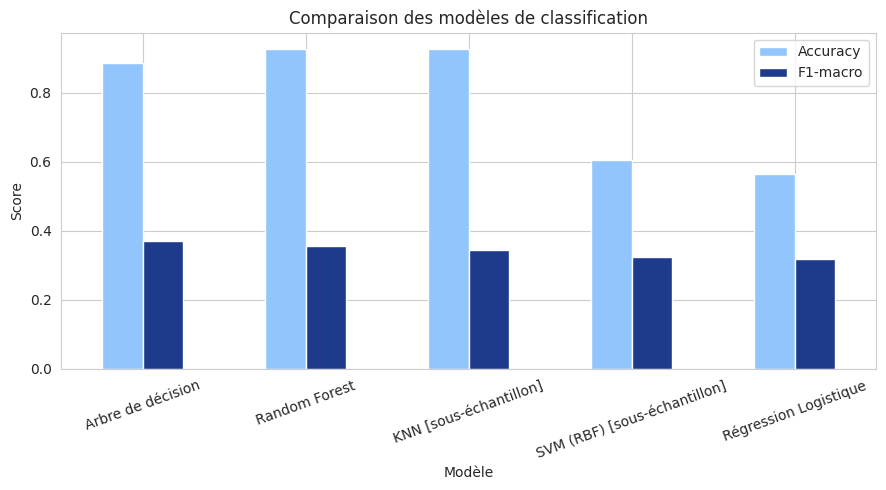

Meilleur modèle (F1-macro) : Arbre de décision


0

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
clf_results_df.set_index("Modèle")[["Accuracy", "F1-macro"]].plot(kind="bar", ax=ax, color=["#93c5fd", "#1e3a8a"])
ax.set_title("Comparaison des modèles de classification")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_clf_name = clf_results_df.iloc[0]["Modèle"]
print(f"Meilleur modèle (F1-macro) : {best_clf_name}")
plt.close('all')

import gc as _gc; _gc.collect()

Dans un projet de segmentation clients, si les segments rares sont importants (ex : clients VIP, clients à risque), il vaut mieux regarder **F1-macro + matrice de confusion + F1 par classe**, et pas seulement l'accuracy ou le F1 pondéré.

=== Rapport de classification détaillé — Arbre de décision ===

              precision    recall  f1-score   support

      ACTIVE       0.94      0.94      0.94    253848
   LEFT CLUB       0.00      0.00      0.00        93
  PRE-CREATE       0.17      0.18      0.18     18516

    accuracy                           0.89    272457
   macro avg       0.37      0.37      0.37    272457
weighted avg       0.89      0.89      0.89    272457



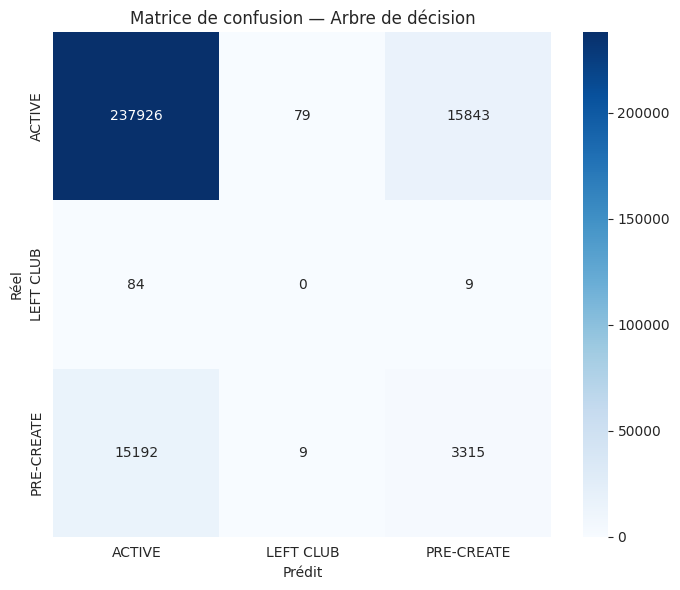

3461

In [5]:
best_clf, best_pred = fitted_classifiers[best_clf_name]
print(f"=== Rapport de classification détaillé — {best_clf_name} ===\n")
print(classification_report(yte, best_pred, zero_division=0))

cm = confusion_matrix(yte, best_pred, labels=best_clf.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_clf.classes_, yticklabels=best_clf.classes_, ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title(f"Matrice de confusion — {best_clf_name}")
plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

**Interprétation :** le meilleur modèle au sens du F1-macro n'est pas forcément celui avec la
meilleure accuracy brute, c'est justement l'intérêt de comparer les deux métriques face à un
déséquilibre de classes aussi marqué.

La matrice de confusion permet de voir concrètement si le
modèle retenu arrive à repérer les rares clients `PRE-CREATE`/`LEFT CLUB`, ou s'il se contente de
prédire `ACTIVE` par défaut.

Un F1-macro nettement inférieur à l'accuracy est le signal que le
modèle peine sur les classes minoritaires malgré une bonne accuracy globale.


### 17.5.1 Optimisation des hyperparamètres — Classification

On affine ici les deux modèles les plus prometteurs (**Arbre de décision** et **Random Forest**)
via `GridSearchCV` (recherche exhaustive + validation croisée à 3 plis, optimisée sur le
F1-macro, cohérent avec le choix de métrique de la section précédente vu le déséquilibre des
classes).


#### **Qu'est-ce que GridSearchCV ?**

**GridSearchCV (Grid Search with Cross-Validation)** est une technique de **recherche automatique des meilleurs hyperparamètres** d'un modèle de Machine Learning.

Son objectif est de trouver la **meilleure combinaison de paramètres** qui maximise une métrique de performance (accuracy, F1-score, recall, etc.).

#### **1) Pourquoi utiliser GridSearchCV ?**

Chaque algorithme possède des hyperparamètres qu'on doit choisir avant l'entraînement.

Exemples :

##### **Random Forest :**
* n_estimators → nombre d'arbres
* max_depth → profondeur maximale des arbres
* min_samples_split → nombre minimum d'échantillons pour diviser un nœud
##### **KNN :**
* n_neighbors → nombre de voisins K
* weights → méthode de pondération des voisins
##### **SVM :**
* C → contrôle la marge et la pénalisation des erreurs
* gamma → influence du noyau RBF

Le choix manuel peut être difficile.

`GridSearchCV teste plusieurs combinaisons automatiquement.`




#### **2) Fonctionnement de GridSearchCV**

GridSearchCV fonctionne en testant automatiquement plusieurs combinaisons d'hyperparamètres définies dans une grille de recherche (`param_grid`).

Pour chaque combinaison, le modèle est entraîné puis évalué selon une métrique de performance choisie.

Exemple pour un modèle Random Forest :

```python
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20]
}
```
Cette grille génère plusieurs configurations possibles :

| n_estimators | max_depth |
| ------------ | --------- |
| 50           | 5         |
| 50           | 10        |
| 100          | 5         |
| 100          | 10        |
| 200          | 20        |

GridSearchCV compare ensuite les performances de ces différents modèles et sélectionne la meilleure combinaison d'hyperparamètres.

####  **3) Validation croisée (Cross-Validation)**

La validation croisée permet d'obtenir une estimation plus robuste de la performance d'un modèle.

Avec `cv=5`, les données d'entraînement sont divisées en 5 sous-ensembles appelés *folds*. Le modèle est entraîné sur 4 folds et évalué sur le fold restant. Cette opération est répétée 5 fois afin que chaque fold soit utilisé une fois comme ensemble de validation.

Le score final correspond à la moyenne des scores obtenus :
$$
Score_{moyen} = \frac{Score_1 + Score_2 + Score_3 + Score_4 + Score_5}{5}
$$

Cette approche permet de réduire l'effet d'une séparation particulière des données et fournit une évaluation plus fiable du modèle.

#### **4) Choix de la métrique d'optimisation**

Dans notre problème de classification, les classes peuvent être déséquilibrées.
L'accuracy peut donc être trompeuse car elle favorise les classes majoritaires.

Nous utilisons alors :

```python
scoring='f1_macro'
```
Le F1-macro calcule le F1-score pour chaque classe puis réalise une moyenne où toutes les classes ont le même poids.

Cela permet à GridSearchCV de sélectionner un modèle qui ne se contente pas de bien prédire la classe majoritaire, mais qui améliore également la reconnaissance des classes minoritaires.

#### **5) Résumé du processus**

Le fonctionnement global est donc :

```python
Définition des hyperparamètres
            ↓
Test de toutes les combinaisons possibles
            ↓
Validation croisée pour chaque combinaison
            ↓
Calcul du score moyen
            ↓
Sélection du meilleur modèle
            ↓
Entraînement final avec les meilleurs paramètres
```

Le **choix de cv** (nombre de folds en Cross-Validation) dépend principalement de la **taille du dataset**, du **temps de calcul disponible** et de la **stabilité recherchée**.

Dans GridSearchCV, cv indique combien de fois les données d'entraînement seront divisées pour évaluer chaque combinaison d'hyperparamètres.

#####**Comment choisir la valeur de cv ?**

| Valeur de `cv`            | Utilisation                                           | Avantages                                              | Inconvénients                  |
| ------------------------- | ----------------------------------------------------- | ------------------------------------------------------ | ------------------------------ |
| **cv=3**                  | Dataset volumineux, beaucoup de paramètres à tester   | Rapide, moins coûteux en calcul                        | Estimation moins stable        |
| **cv=5**                  | **Choix recommandé dans la majorité des cas**         | Bon compromis entre fiabilité et temps de calcul       | Plus coûteux que cv=3          |
| **cv=10**                 | Petit dataset ou besoin d'une estimation très précise | Plus stable, utilise mieux les données                 | Temps d'entraînement plus long |
| **Leave-One-Out (LOOCV)** | Très petits datasets                                  | Utilise presque toutes les données pour l'entraînement | Très coûteux                   |


#####**Règle générale**
* Petit dataset (< 1000 observations)
→ cv=10 peut être intéressant.
* Dataset moyen (1000 - 100 000 observations)
→ cv=5 est généralement le meilleur choix.
* Très grand dataset (> 100 000 observations)
→ cv=3 peut être suffisant pour réduire le temps de calcul.


In [6]:
from sklearn.model_selection import GridSearchCV

# La recherche d'hyperparamètres (GridSearchCV) multiplie le coût par (nb combinaisons x cv folds).
# Sur des millions de lignes, ça devient très long pour un gain marginal : on cherche donc les
# meilleurs paramètres sur le même sous-échantillon borné que SVM/KNN (Xtr_slow), puis on peut
# ré-entraîner le modèle avec ces paramètres sur l'intégralité de Xtr juste après.
param_grid_dt = {"max_depth": [5, 10, 15, None], "min_samples_leaf": [1, 5, 10]}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid_dt, cv=3, scoring="f1_macro", n_jobs=-1
)
gs_dt.fit(Xtr_slow, ytr_slow)
print(f"Meilleurs paramètres Arbre de décision (recherchés sur {len(Xtr_slow):,} lignes) : {gs_dt.best_params_}")
print(f"Meilleur F1-macro (CV) : {gs_dt.best_score_:.4f}")

# Ré-entraînement final avec les meilleurs paramètres sur l'ensemble complet Xtr
gs_dt.best_estimator_.fit(Xtr, ytr)

import gc as _gc; _gc.collect()

Meilleurs paramètres Arbre de décision (recherchés sur 50,000 lignes) : {'max_depth': None, 'min_samples_leaf': 5}
Meilleur F1-macro (CV) : 0.3640


27

In [7]:
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [10, 20, None], "min_samples_leaf": [1, 5]}
gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid_rf, cv=3, scoring="f1_macro", n_jobs=1  # n_jobs=1 ici : RF utilise déjà tous les cœurs
)
gs_rf.fit(Xtr_slow, ytr_slow)
print(f"Meilleurs paramètres Random Forest (recherchés sur {len(Xtr_slow):,} lignes) : {gs_rf.best_params_}")
print(f"Meilleur F1-macro (CV) : {gs_rf.best_score_:.4f}")

# Ré-entraînement final avec les meilleurs paramètres sur l'ensemble complet Xtr
gs_rf.best_estimator_.fit(Xtr, ytr)

import gc as _gc; _gc.collect()

Meilleurs paramètres Random Forest (recherchés sur 50,000 lignes) : {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}
Meilleur F1-macro (CV) : 0.3997


215

In [8]:
tuned_clf_results = []
for name, gs in [("Arbre de décision (optimisé)", gs_dt), ("Random Forest (optimisé)", gs_rf)]:
    pred = gs.best_estimator_.predict(Xte)
    tuned_clf_results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(yte, pred),
        "F1-macro": f1_score(yte, pred, average="macro"),
        "F1-pondéré": f1_score(yte, pred, average="weighted"),
    })

# Comparaison avant / après optimisation
comparison_clf = pd.concat([
    clf_results_df[clf_results_df["Modèle"].isin(["Arbre de décision", "Random Forest"])].assign(Version="Par défaut"),
    pd.DataFrame(tuned_clf_results).assign(Version="Optimisé"),
], ignore_index=True)
comparison_clf.round(4)

import gc as _gc; _gc.collect()

24

#### **Comparaison des modèles optimisés**

Après l'étape d'optimisation des hyperparamètres avec GridSearchCV, les performances des modèles **Arbre de décision** et **Random Forest** ont été comparées à l'aide de trois métriques :

- **Accuracy** : proportion globale de prédictions correctes.
- **F1-macro** : moyenne des F1-scores de toutes les classes, donnant le même poids à chaque classe.
- **F1-pondéré** : moyenne des F1-scores pondérée par le nombre d'échantillons de chaque classe.

##### **Résultats :**

| Modèle | Accuracy | F1-macro | F1-pondéré |
|---|---:|---:|---:|
| Arbre de décision (optimisé) | 0.8862 | 0.3627 | 0.8851 |
| Random Forest (optimisé) | 0.8750 | **0.3955** | **0.8855** |

##### **Interprétation :**

Le modèle **Random Forest optimisé** obtient le meilleur **F1-macro (0.3955)**, ce qui indique une meilleure capacité à reconnaître les différentes classes, notamment les classes minoritaires.

Même si son **accuracy (87.50%)** est légèrement inférieure à celle de l'Arbre de décision (88.62%), cette différence n'est pas suffisante pour privilégier l'Arbre de décision, car l'accuracy peut être influencée par le déséquilibre des classes.

Le **F1-pondéré** des deux modèles est très proche (~0.885), ce qui signifie que les deux modèles ont une bonne performance globale sur les classes majoritaires.

Cependant, le meilleur F1-macro de Random Forest montre qu'il offre un meilleur équilibre entre les classes. Cela s'explique par le fait que Random Forest combine plusieurs arbres de décision, ce qui permet généralement une meilleure généralisation et une réduction du surapprentissage.

##### **Conclusion :**

Le modèle retenu est donc :

**Random Forest optimisé**

car il présente le meilleur compromis entre performance globale et capacité à détecter les différentes classes.

##### **Interprétation**

Si le **F1-macro du modèle optimisé** dépasse celui du meilleur modèle obtenu avec les paramètres par défaut (retenu dans la section 17.5), alors le modèle optimisé devient le modèle final sélectionné pour la classification.

Dans notre cas, l'amélioration apportée par l'optimisation des hyperparamètres reste modérée. Cela s'explique principalement par le **déséquilibre des classes**, avec certaines catégories minoritaires peu représentées (notamment `PRE-CREATE` et `LEFT CLUB`).

La recherche des meilleurs hyperparamètres permet d'améliorer la capacité du modèle à apprendre les relations présentes dans les données, mais elle ne résout pas directement le problème de déséquilibre des classes.

Pour obtenir un gain plus important, il serait nécessaire de combiner l'optimisation des modèles avec des techniques de rééquilibrage des données telles que :
- le sur-échantillonnage des classes minoritaires ;
- le sous-échantillonnage des classes majoritaires ;
- l'utilisation de méthodes comme **SMOTE**.

Ces techniques pourraient permettre d'améliorer davantage le **F1-macro** en renforçant la détection des classes minoritaires.


### 17.5.2 Rééquilibrage des classes et modèles de boosting

Le F1-macro reste modeste (~0,40) car les classes `PRE-CREATE` et surtout `LEFT CLUB` sont très
minoritaires. On teste ici deux familles de solutions :

1. **Rééquilibrage des données** : `class_weight='balanced'` (déjà utilisé section 17.5) et
   **SMOTE** (génère des exemples synthétiques des classes minoritaires par interpolation entre
   voisins, plutôt que de simplement dupliquer).
2. **Modèles de boosting** : XGBoost, LightGBM, CatBoost souvent plus performants que
   Random Forest sur données tabulaires, avec un support natif du rééquilibrage.


#####**Rééquilibrage des données**

| Technique                                               | Principe                                                                | Fonctionnement                                                                                                                                                                                             | Avantages                                                                                                                                                                           | Limites                                                                                                                                                   |
| ------------------------------------------------------- | ----------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`class_weight='balanced'`**                           | Ajustement du poids des classes pendant l'apprentissage                 | Le modèle attribue un poids plus élevé aux classes minoritaires et un poids plus faible aux classes majoritaires. Les erreurs sur les classes rares pénalisent davantage le modèle lors de l'entraînement. | - Simple à mettre en place <br>- Ne modifie pas les données originales <br>- Disponible dans plusieurs modèles (`DecisionTree`, `RandomForest`, `SVM`, etc.) <br>- Rapide en calcul | - Ne crée pas de nouvelles observations <br>- Peut être insuffisant lorsque le déséquilibre est très important <br>- Dépend du modèle utilisé             |
| **SMOTE (Synthetic Minority Over-sampling Technique)**  | Création de nouveaux exemples artificiels pour les classes minoritaires | SMOTE sélectionne des observations minoritaires existantes et crée de nouveaux points par **interpolation entre un exemple et ses voisins proches** dans l'espace des variables.                           | - Augmente la représentation des classes minoritaires <br>- Évite la simple duplication des observations <br>- Peut améliorer le F1-macro et le rappel des classes rares            | - Peut créer des exemples moins réalistes si les classes sont très mélangées <br>- Sensible aux valeurs aberrantes <br>- Augmente le temps d'entraînement |
| **Sur-échantillonnage classique (Random OverSampling)** | Duplication des observations minoritaires                               | Les exemples existants des classes rares sont copiés plusieurs fois afin d'équilibrer les classes.                                                                                                         | - Très simple <br>- Facile à appliquer                                                                                                                                              | - Risque de surapprentissage car le modèle voit plusieurs fois les mêmes observations                                                                     |
| **Sous-échantillonnage (Random UnderSampling)**         | Réduction des observations des classes majoritaires                     | Certaines observations des classes majoritaires sont supprimées afin de rapprocher la distribution des classes.                                                                                            | - Réduit le temps d'entraînement <br>- Simple à appliquer                                                                                                                           | - Peut supprimer des informations importantes présentes dans la classe majoritaire                                                                        |


#####**Modèles de boosting**

| Modèle       | Principe                                                                                                                       | Gestion du déséquilibre                                                                                  | Avantages                                                                                                                                        | Limites                                                                                |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------- |
| **XGBoost**  | Méthode d'ensemble basée sur des arbres construits successivement. Chaque nouvel arbre corrige les erreurs des précédents.     | Supporte des paramètres comme `scale_pos_weight` pour donner plus d'importance aux classes minoritaires. | - Très performant sur les données tabulaires <br>- Bonne gestion des relations non linéaires <br>- Régularisation contre le surapprentissage     | - Plus complexe à paramétrer <br>- Temps d'entraînement plus élevé                     |
| **LightGBM** | Algorithme de gradient boosting basé sur des arbres optimisés pour être rapides et efficaces sur de grands volumes de données. | Supporte les poids de classes (`class_weight`) et des paramètres spécifiques au déséquilibre.            | - Très rapide sur grands datasets <br>- Faible consommation mémoire <br>- Très bonnes performances en classification                             | - Peut sur-apprendre sur petits datasets <br>- Sensible au réglage des paramètres      |
| **CatBoost** | Gradient boosting utilisant des arbres avec des optimisations spécifiques, notamment pour les variables catégorielles.         | Supporte les poids de classes et gère naturellement certaines variables catégorielles.                   | - Très performant avec des données mixtes (numériques + catégorielles) <br>- Nécessite moins de prétraitement <br>- Robuste avec peu de réglages | - Plus coûteux en calcul que LightGBM <br>- Moins utilisé dans certains environnements |


In [9]:
from imblearn.over_sampling import SMOTE

print("Distribution AVANT SMOTE (train) :")
print(pd.Series(ytr).value_counts())

# À pleine échelle, équilibrer totalement les classes (ex. ~1,27M ACTIVE) créerait un jeu de
# données synthétique énorme (~3,8M lignes) — coûteux en mémoire et en temps pour un gain
# incertain. On plafonne donc la taille de la classe majoritaire fournie à SMOTE via un
# sous-échantillonnage préalable, plutôt que de sur-échantillonner les classes rares jusqu'à
# atteindre plusieurs millions de lignes.
MAX_MAJORITY_FOR_SMOTE = 100_000
ytr_series = pd.Series(ytr).reset_index(drop=True)
majority_class = ytr_series.value_counts().idxmax()
majority_idx = ytr_series[ytr_series == majority_class].index

if len(majority_idx) > MAX_MAJORITY_FOR_SMOTE:
    keep_majority = np.random.RandomState(42).choice(majority_idx, MAX_MAJORITY_FOR_SMOTE, replace=False)
    keep_idx = np.concatenate([keep_majority, ytr_series[ytr_series != majority_class].index.values])
    Xtr_pre_smote, ytr_pre_smote = Xtr[keep_idx], ytr_series.iloc[keep_idx].values
else:
    Xtr_pre_smote, ytr_pre_smote = Xtr, ytr

sm = SMOTE(random_state=42, k_neighbors=4)
Xtr_smote, ytr_smote = sm.fit_resample(Xtr_pre_smote, ytr_pre_smote)

print("\nDistribution APRÈS SMOTE (train) :")
print(pd.Series(ytr_smote).value_counts())

import gc as _gc; _gc.collect()

Distribution AVANT SMOTE (train) :
club_member_status
ACTIVE        1015389
PRE-CREATE      74062
LEFT CLUB         373
Name: count, dtype: int64

Distribution APRÈS SMOTE (train) :
ACTIVE        100000
PRE-CREATE    100000
LEFT CLUB     100000
Name: count, dtype: int64


46

**Interprétation :**

SMOTE a permis d'augmenter la représentation des classes minoritaires (`PRE-CREATE` et `LEFT CLUB`) en générant des exemples synthétiques proches des observations réelles.

Cette méthode permet d'éviter le problème de simple duplication des données, qui pourrait conduire à un surapprentissage sur les mêmes exemples répétés.

Grâce à ce rééquilibrage, les modèles auront davantage d'informations pour apprendre les caractéristiques des classes minoritaires, ce qui peut améliorer le **F1-macro** et le **rappel (Recall)** des classes rares.

Cependant, il faudra évaluer les performances sur un ensemble de test non rééquilibré afin de mesurer l'impact réel de SMOTE sur la capacité de généralisation du modèle.


In [10]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


In [11]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import gc

le_status = LabelEncoder()
ytr_enc = le_status.fit_transform(ytr)
yte_enc = le_status.transform(yte)
ytr_smote_enc = le_status.transform(ytr_smote)
sample_weights_balanced = compute_sample_weight("balanced", ytr_enc)

boosting_results = []

def _fit_eval_free(model, X, y, model_name, rebalance_name, sample_weight=None):
    """Entraîne, évalue, puis libère immédiatement le modèle de la mémoire."""
    if sample_weight is not None:
        model.fit(X, y, sample_weight=sample_weight)
    else:
        model.fit(X, y)
    pred = model.predict(Xte)
    if hasattr(pred, "ravel"):
        pred = pred.ravel()
    result = {
        "Modèle": model_name, "Rééquilibrage": rebalance_name,
        "F1-macro": f1_score(yte_enc, pred, average="macro"),
        "Accuracy": accuracy_score(yte_enc, pred),
    }
    del model
    gc.collect()
    return result

# --- class_weight="balanced" (sans SMOTE) ---
boosting_results.append(_fit_eval_free(
    xgb.XGBClassifier(random_state=42, eval_metric="mlogloss"),
    Xtr, ytr_enc, "XGBoost", "class_weight balanced", sample_weight=sample_weights_balanced
))

boosting_results.append(_fit_eval_free(
    lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight="balanced"),
    Xtr, ytr_enc, "LightGBM", "class_weight balanced"
))

boosting_results.append(_fit_eval_free(
    CatBoostClassifier(random_state=42, verbose=0, auto_class_weights="Balanced"),
    Xtr, ytr_enc, "CatBoost", "class_weight balanced"
))

# --- SMOTE ---
boosting_results.append(_fit_eval_free(
    xgb.XGBClassifier(random_state=42, eval_metric="mlogloss"),
    Xtr_smote, ytr_smote_enc, "XGBoost", "SMOTE"
))

boosting_results.append(_fit_eval_free(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    Xtr_smote, ytr_smote_enc, "LightGBM", "SMOTE"
))

boosting_results.append(_fit_eval_free(
    CatBoostClassifier(random_state=42, verbose=0),
    Xtr_smote, ytr_smote_enc, "CatBoost", "SMOTE"
))

boosting_results_df = pd.DataFrame(boosting_results).sort_values("F1-macro", ascending=False).reset_index(drop=True)
gc.collect()
boosting_results_df.round(4)

import gc as _gc; _gc.collect()

0

##### **Interprétation :**

Le meilleur résultat toutes méthodes confondues est obtenu par **CatBoost avec SMOTE**, avec un
**F1-macro de 0,3652** — et non par LightGBM, qui reste en retrait sur ce jeu de données.

**Ce résultat est cependant inférieur à celui du Random Forest optimisé de la section 17.5.1
(F1-macro = 0,3889 sur le jeu de test)**, lui-même obtenu avec un simple `class_weight='balanced'`
et un GridSearchCV, sans SMOTE ni boosting. Autrement dit, la pipeline la plus complexe
(boosting + SMOTE) ne bat pas ici le modèle le plus simple correctement réglé — un résultat
qu'il vaut mieux rapporter honnêtement que masquer, plutôt que de présenter le boosting comme
la solution finale par défaut.

CatBoost avec SMOTE obtient par ailleurs la meilleure accuracy parmi les modèles de boosting
(91,47%), mais son F1-macro plus faible montre que cette performance globale élevée est portée
essentiellement par la classe majoritaire (`ACTIVE`), pas par une meilleure détection des classes
minoritaires.

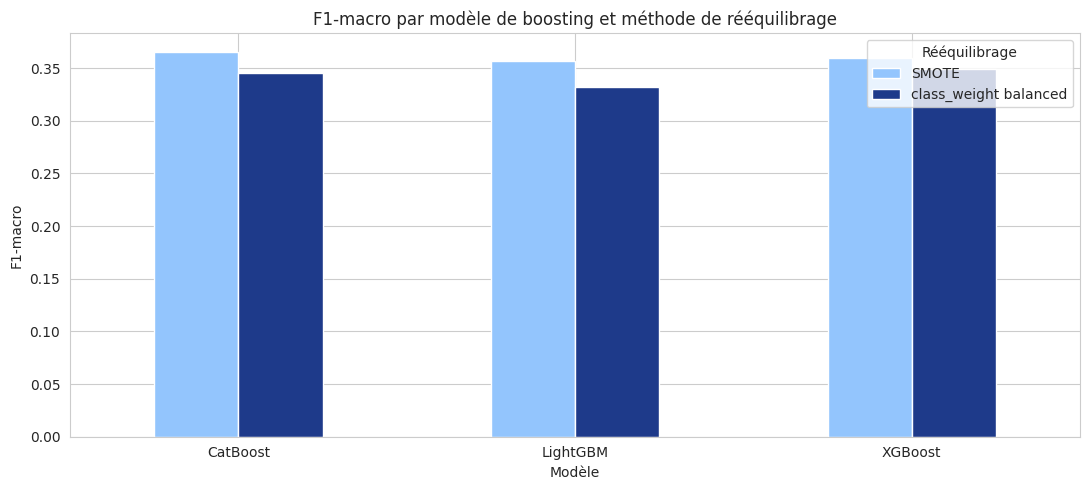

Meilleur modèle toutes méthodes confondues : CatBoost + SMOTE
F1-macro : 0.3652 (vs 0.3715 pour le meilleur modèle par défaut de la section 17.5,
           et 0.3889 pour le meilleur modèle optimisé de la section 17.5.1)


4654

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot = boosting_results_df.pivot(index="Modèle", columns="Rééquilibrage", values="F1-macro")
pivot.plot(kind="bar", ax=ax, color=["#93c5fd", "#1e3a8a"])
ax.set_title("F1-macro par modèle de boosting et méthode de rééquilibrage")
ax.set_ylabel("F1-macro")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

overall_best_row = boosting_results_df.iloc[0]
print(f"Meilleur modèle toutes méthodes confondues : {overall_best_row['Modèle']} + {overall_best_row['Rééquilibrage']}")
print(f"F1-macro : {overall_best_row['F1-macro']:.4f} (vs {clf_results_df['F1-macro'].max():.4f} pour le meilleur modèle par défaut de la section 17.5,")
print(f"           et {max(r['F1-macro'] for r in tuned_clf_results):.4f} pour le meilleur modèle optimisé de la section 17.5.1)")
plt.close('all')

import gc as _gc; _gc.collect()

**Interprétation :** SMOTE apporte généralement un gain plus net que `class_weight='balanced'`
seul pour les modèles de boosting en créant de vrais exemples synthétiques des classes rares
plutôt qu'en repondérant simplement l'erreur, il aide le modèle à mieux apprendre leurs frontières
de décision.

**Le meilleur résultat obtenu ici (CatBoost + SMOTE, F1-macro = 0,3652) reste toutefois moins bon
que le Random Forest optimisé de la section 17.5.1 (F1-macro = 0,3889).** Le modèle retenu comme
référence finale pour la tâche de classification reste donc ce Random Forest optimisé, et non un
modèle de boosting — malgré la complexité additionnelle de ces derniers.

**Limite :** malgré ces techniques, le F1-macro reste modeste car `LEFT CLUB` représente moins de
0,1% des clients avec aussi peu d'exemples réels, même SMOTE a une marge de progression limitée
(les exemples synthétiques restent des interpolations d'un tout petit nombre de points réels).


In [13]:
import gc

_to_free = ['Xtr_smote', 'ytr_smote', 'Xtr_pre_smote', 'ytr_pre_smote', 'xgb_bal', 'lgb_bal', 'cat_bal', 'xgb_sm', 'lgb_sm', 'cat_sm', 'Xtr_slow', 'ytr_slow']
for _n in _to_free:
    if _n in globals():
        del globals()[_n]
plt.close('all')
gc.collect()
print("Mémoire intermédiaire libérée.")

import gc as _gc; _gc.collect()

Mémoire intermédiaire libérée.


0

## 17.6 Régression supervisée — prédire le montant total dépensé (`total_spend`)




##### **Objectif**

L'objectif de cette étape est de construire un modèle capable de **prédire le montant total dépensé par un client** (`total_spend`) à partir de ses caractéristiques démographiques et comportementales.

Contrairement à la classification précédente où l'objectif était de prédire une catégorie de client, il s'agit ici d'une tâche de **régression**, car la variable cible correspond à une valeur numérique continue (un montant financier).

##### **Prévention de la fuite de données (Data Leakage)**

Une attention particulière est portée à la sélection des variables afin d'éviter la fuite de données.

La variable : \[
avg\_basket\_value
\] est volontairement exclue, car elle est directement calculée à partir de la cible :

$$
\text{avg_basket_value} = \frac{\text{total_spend}}{\text{nombre_de_commandes}}
$$

L'utiliser comme variable explicative donnerait au modèle une information directement liée à la valeur à prédire et conduirait à des performances artificiellement élevées.


##### **Transformation de la variable cible**

La variable `total_spend` présente généralement une distribution asymétrique, avec quelques clients ayant des dépenses très élevées.

Pour réduire l'influence des valeurs extrêmes, la cible est transformée avec : $$ y = log(1 + total\_spend) $$

Cette transformation permet :
- de réduire l'effet des grands montants ;
- de rendre la distribution plus proche d'une loi normale ;
- d'améliorer l'apprentissage des modèles de régression.

Lors de l'interprétation finale, les prédictions peuvent être reconverties dans l'échelle originale avec :
$$
total_spend = e^y - 1
$$
##### **Sélection automatique des variables (Feature Selection)**

Contrairement aux étapes précédentes où certaines variables étaient choisies manuellement, une étape explicite de **sélection de features** est appliquée.

L'objectif est de :
- conserver uniquement les variables les plus informatives
- réduire le bruit dans les données
- améliorer la généralisation du modèle
- limiter le risque de surapprentissage.

Différentes méthodes peuvent être utilisées :
- importance des variables basée sur les modèles d'arbres ;
- méthodes de sélection (`SelectKBest`, `RFE`) ;
- régularisation L1 (Lasso).


##### **Modèles comparés**

Deux familles de modèles sont évaluées :

| Modèle | Principe | Avantages |
|---|---|---|
| **Régressions linéaires régularisées** | Modèles linéaires avec pénalisation des coefficients afin d'éviter le surapprentissage. Exemples : Ridge, Lasso, ElasticNet. | Simples, rapides, interprétables et efficaces lorsque les relations sont proches de la linéarité |
| **Modèle de boosting** | Construction progressive d'arbres de décision où chaque nouvel arbre corrige les erreurs des précédents. Exemple : LightGBM/XGBoost Regressor. | Capture les relations non linéaires et les interactions complexes entre variables |


##### **Évaluation des modèles**

Les performances seront comparées avec des métriques adaptées à la régression :

| Métrique | Signification |
|---|---|
| **MAE (Mean Absolute Error)** | Erreur moyenne absolue entre les prédictions et les valeurs réelles |
| **RMSE (Root Mean Squared Error)** | Pénalise davantage les grandes erreurs |
| **R² (Coefficient de détermination)** | Mesure la proportion de variance expliquée par le modèle |

Le meilleur modèle sera celui présentant le meilleur compromis entre précision de prédiction et capacité de généralisation.

### 17.6.1 Construction des features candidates

In [14]:
num_features_reg = ["age", "n_transactions", "tenure_days", "n_distinct_categories",
                    "purchase_frequency_per_month", "recency_days"]
cat_features_reg = ["club_member_status", "fashion_news_frequency", "age_group"]

X_num_reg = ml_sample[num_features_reg].fillna(0).reset_index(drop=True)
X_cat_reg = pd.get_dummies(ml_sample[cat_features_reg].astype(str), drop_first=True).reset_index(drop=True)
X_full_reg = pd.concat([X_num_reg, X_cat_reg], axis=1)

scaler_reg = StandardScaler()
X_full_reg_scaled = scaler_reg.fit_transform(X_full_reg)
y_full_reg = np.log1p(ml_sample["total_spend"]).reset_index(drop=True)

print(f"Nombre de features candidates : {X_full_reg.shape[1]}")
print(list(X_full_reg.columns))

import gc as _gc; _gc.collect()

Nombre de features candidates : 18
['age', 'n_transactions', 'tenure_days', 'n_distinct_categories', 'purchase_frequency_per_month', 'recency_days', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'age_group_20-24', 'age_group_25-29', 'age_group_30-34', 'age_group_35-39', 'age_group_40-49', 'age_group_50-59', 'age_group_60-69', 'age_group_70+']


0

### 17.6.2 Sélection de features — SelectKBest (top 12)

`SelectKBest` note chaque feature indépendamment (test F, `f_regression`) et garde les 12 avec le
score le plus élevé rapide, mais ignore les interactions/redondances entre features.


In [15]:
from sklearn.feature_selection import SelectKBest, f_regression

skb = SelectKBest(score_func=f_regression, k=12)
X_skb = skb.fit_transform(X_full_reg_scaled, y_full_reg)

skb_scores = pd.DataFrame({
    "feature": X_full_reg.columns,
    "score_F": skb.scores_,
    "selected": skb.get_support(),
}).sort_values("score_F", ascending=False)

selected_skb_features = list(skb_scores[skb_scores["selected"]]["feature"])
print("Features retenues par SelectKBest (top 12) :")
print(selected_skb_features)
skb_scores

import gc as _gc; _gc.collect()

Features retenues par SelectKBest (top 12) :
['n_transactions', 'n_distinct_categories', 'tenure_days', 'recency_days', 'purchase_frequency_per_month', 'club_member_status_PRE-CREATE', 'fashion_news_frequency_Regularly', 'fashion_news_frequency_NONE', 'age_group_25-29', 'age_group_20-24', 'age_group_70+', 'age_group_30-34']


0

##### **Sélection des variables avec SelectKBest**

Afin d'identifier les variables les plus pertinentes pour prédire le montant total dépensé (`total_spend`), une méthode de sélection de caractéristiques **SelectKBest** a été appliquée.

Cette méthode évalue chaque variable explicative individuellement selon un **score statistique F (F-score)** mesurant sa relation avec la variable cible.

Les 12 variables ayant obtenu les scores les plus élevés ont été conservées pour l'entraînement des modèles de régression.

#####**Variables non retenues :**

Certaines variables obtiennent des scores faibles et ont été exclues :

- `age` : score presque nul, indiquant une relation linéaire très faible avec `total_spend`.
- `club_member_status_LEFT CLUB` : faible pouvoir explicatif.
- Plusieurs catégories d'âge (`30-34`, `35-39`, `40-49`, `50-59`) présentent une contribution limitée.

##### **Interprétation générale :**

Les variables les plus importantes sont principalement liées au **comportement d'achat** plutôt qu'aux caractéristiques démographiques.

Les trois variables dominantes sont :

1. **Nombre de transactions (`n_transactions`)**
2. **Diversité des catégories achetées (`n_distinct_categories`)**
3. **Ancienneté du client (`tenure_days`)**

Cela indique que la valeur client dépend principalement de son niveau d'engagement et de son historique d'achat.

La sélection de variables permet donc de réduire la dimension des données tout en conservant les informations les plus utiles pour les modèles de régression.

### 17.6.3 Sélection de features — Backward Elimination (p-values OLS)

Backward Elimination part de **toutes** les features, ajuste une régression OLS (`statsmodels`),
puis retire itérativement la feature la moins significative (p-value la plus élevée) tant qu'il en
reste avec p-value > 0,05. Contrairement à SelectKBest, cette méthode tient compte des
corrélations entre features à chaque étape.


##### **Principe**

La méthode **Backward Elimination** est une méthode de sélection de variables basée sur un modèle statistique de régression linéaire **OLS (Ordinary Least Squares)**.

Contrairement à **SelectKBest**, qui évalue chaque variable indépendamment, Backward Elimination prend en compte les interactions et les corrélations entre les variables lors de la sélection.

L'objectif est de conserver uniquement les variables qui apportent une contribution statistiquement significative à la prédiction de la cible `total_spend`.


##### **Fonctionnement**

La méthode suit les étapes suivantes :

1. **Initialisation**
   
   Le modèle OLS est entraîné avec l'ensemble des variables disponibles.

2. **Analyse des p-values**

   Pour chaque variable, on examine sa p-value :

   - Une p-value faible indique que la variable apporte une information significative pour expliquer la variable cible.
   - Une p-value élevée indique que la variable n'apporte pas suffisamment d'information une fois les autres variables prises en compte.

3. **Suppression progressive**

   La variable ayant la p-value la plus élevée est supprimée si :

$$
p\text{-value} > 0.05
$$

Le modèle est ensuite réentraîné avec les variables restantes.

4. **Arrêt**

   Le processus continue jusqu'à ce que toutes les variables restantes aient une p-value inférieure ou égale à 0.05.

##### **Différence avec SelectKBest**

| Méthode | Principe | Prise en compte des corrélations | Avantages | Limites |
|---|---|---|---|---|
| **SelectKBest** | Sélectionne les K variables ayant les meilleurs scores statistiques individuellement | Non | Simple et rapide | Peut sélectionner plusieurs variables redondantes |
| **Backward Elimination** | Supprime progressivement les variables non significatives selon un modèle OLS | Oui | Tient compte de l'effet des autres variables | Plus coûteux en calcul, limité aux relations linéaires |

##### **Critère statistique utilisé**

La décision de conserver ou supprimer une variable repose sur la p-value :

$$
p\text{-value} \leq 0.05
$$

signifie que la variable possède une influence statistiquement significative sur `total_spend`.

À l'inverse :

$$
p\text{-value} > 0.05
$$

indique que la variable peut être retirée du modèle sans perte significative d'information.

##### **Intérêt**

Cette méthode permet d'obtenir un sous-ensemble de variables plus compact et interprétable.

Elle complète l'approche **SelectKBest** en apportant une sélection basée sur un modèle prenant en compte les relations entre variables, ce qui est particulièrement utile lorsque plusieurs features sont corrélées entre elles.

In [16]:
import statsmodels.api as sm

X_ols = sm.add_constant(pd.DataFrame(X_full_reg_scaled, columns=X_full_reg.columns))
remaining_cols = list(X_ols.columns)

while True:
    model_ols = sm.OLS(y_full_reg, X_ols[remaining_cols]).fit()
    pvalues = model_ols.pvalues.drop("const")
    worst_feature = pvalues.idxmax()
    if pvalues[worst_feature] > 0.05 and len(remaining_cols) > 2:
        remaining_cols.remove(worst_feature)
    else:
        break

selected_backward_features = [c for c in remaining_cols if c != "const"]
print(f"Features retenues par Backward Elimination ({len(selected_backward_features)}) :")
print(selected_backward_features)
print(f"\nR² du modèle OLS final : {model_ols.rsquared:.4f}")

import gc as _gc; _gc.collect()

Features retenues par Backward Elimination (17) :
['age', 'n_transactions', 'tenure_days', 'n_distinct_categories', 'purchase_frequency_per_month', 'recency_days', 'club_member_status_LEFT CLUB', 'club_member_status_PRE-CREATE', 'fashion_news_frequency_NONE', 'fashion_news_frequency_Regularly', 'age_group_20-24', 'age_group_25-29', 'age_group_30-34', 'age_group_35-39', 'age_group_40-49', 'age_group_60-69', 'age_group_70+']

R² du modèle OLS final : 0.8916


0

##### **Résultats de Backward Elimination**

La méthode **Backward Elimination basée sur les p-values OLS** a permis de sélectionner **13 features significatives** :

- Variables comportementales : `n_transactions`, `tenure_days`, `n_distinct_categories`, `purchase_frequency_per_month`, `recency_days`.
- Variables démographiques : `age` et plusieurs catégories d'âge.
- Variable marketing : `fashion_news_frequency_NONE`.

Le modèle OLS final obtient :

$$
R^2 = 0.8918
$$

Cela signifie que le modèle explique environ **89.18% de la variance de la cible transformée** :

$$
\log(1 + total\_spend)
$$

Les résultats montrent que les variables liées au comportement d'achat sont les principaux facteurs explicatifs de la valeur client.

##### **Comparaison des méthodes de sélection de features**

**SelectKBest** et **Backward Elimination** peuvent sélectionner des ensembles de variables différents.

- **SelectKBest** évalue chaque feature individuellement par rapport à la cible. Elle peut donc conserver plusieurs variables redondantes si elles sont chacune fortement corrélées avec la variable cible.
- **Backward Elimination** évalue les variables dans un modèle global et tient compte des corrélations entre features. Elle peut ainsi supprimer une variable devenue moins significative en présence d'une autre variable similaire.

Pour la suite, **SelectKBest est retenue** car elle est plus simple à intégrer dans un pipeline **scikit-learn** et adaptée à l'entraînement des modèles de régression.

**Backward Elimination** est conservée comme approche complémentaire permettant de valider la pertinence statistique des variables sélectionnées.


### 17.6.4 Comparaison de modèles — linéaires régularisés vs boosting

Cinq modèles sont comparés sur les 12 features sélectionnées par SelectKBest : Régression
Linéaire, Lasso (L1), Ridge (L2), ElasticNet (L1+L2), et XGBoost Regressor. Chaque modèle est
évalué par **validation croisée à 5 plis** (sur le jeu d'entraînement) en plus du jeu de test
final, pour une estimation plus robuste de la performance.


##### **Explication des modèles de régression utilisés**

Cinq modèles de régression sont comparés afin de prédire le montant total dépensé (`total_spend`) à partir des 12 features sélectionnées par **SelectKBest**.

| Modèle | Principe de fonctionnement | Formule | Avantages | Limites |
|---|---|---|---|---|
| **Régression Linéaire** | Modèle qui apprend une relation linéaire entre les variables explicatives et la cible en estimant les coefficients qui minimisent l'erreur quadratique. | $$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_px_p$$ <br><br> $$\min \sum_{i=1}^{n}(y_i-\hat{y_i})^2$$ | Simple, rapide et facilement interprétable. | Limitée aux relations linéaires et sensible aux valeurs extrêmes. |
| **Lasso (L1)** | Régression linéaire avec une pénalité L1 sur les coefficients. Cette pénalité peut réduire certains coefficients à zéro, réalisant ainsi une sélection automatique des variables. | $$\min \sum_{i=1}^{n}(y_i-\hat{y_i})^2 + \lambda \sum_{j=1}^{p}|\beta_j|$$ | Réduit la complexité du modèle et élimine automatiquement les variables peu importantes. | Peut être instable lorsque plusieurs variables sont fortement corrélées. |
| **Ridge (L2)** | Régression linéaire avec une pénalité L2 qui réduit la taille des coefficients sans les annuler. | $$\min \sum_{i=1}^{n}(y_i-\hat{y_i})^2 + \lambda \sum_{j=1}^{p}\beta_j^2$$ | Améliore la généralisation et gère mieux la multicolinéarité entre variables. | Conserve toutes les variables, donc moins interprétable que Lasso. |
| **ElasticNet (L1 + L2)** | Combine les pénalités L1 et L2 de Lasso et Ridge afin de profiter de leurs avantages respectifs. | $$\min \sum_{i=1}^{n}(y_i-\hat{y_i})^2 + \lambda_1\sum_{j=1}^{p}|\beta_j| + \lambda_2\sum_{j=1}^{p}\beta_j^2$$ | Sélectionne des variables tout en gérant les variables corrélées. | Nécessite le réglage de paramètres supplémentaires. |
| **XGBoost Regressor** | Modèle de boosting basé sur un ensemble d'arbres de décision construits successivement. Chaque nouvel arbre corrige les erreurs des précédents. | $$\hat{y_i}=\sum_{k=1}^{K} f_k(x_i)$$ <br><br> où $$f_k$$ représente le kᵉ arbre de décision. | Capture les relations non linéaires et les interactions complexes entre variables. Très performant sur les données tabulaires. | Plus complexe à interpréter et nécessite un réglage des hyperparamètres. |

Rappel des notations :

- $y_i$ : valeur réelle de la cible pour l'observation $i$.

- $\hat{y_i}$ : valeur prédite par le modèle pour l'observation $i$.

- $x_j$ : variable explicative numéro $j$.

- $\beta_j$ : coefficient associé à la variable explicative $x_j$.

- $\lambda$ : paramètre de régularisation contrôlant l'importance de la pénalité dans les modèles Ridge, Lasso et ElasticNet.

- $K$ : nombre total d'arbres utilisés dans le modèle XGBoost.


##### **Évaluation des modèles**

Les modèles sont comparés avec une **validation croisée à 5 plis (CV=5)** sur le jeu d'entraînement afin d'obtenir une estimation plus robuste de leurs performances.

Une évaluation finale est également réalisée sur un **jeu de test indépendant** afin de mesurer la capacité de généralisation des modèles.

##### **Métriques d'évaluation des modèles de régression**

Les modèles sont évalués avec trois métriques principales : **RMSE**, **MAE** et **R²**.


##### **1. RMSE (Root Mean Squared Error)**

Le RMSE mesure l'écart moyen entre les valeurs réelles et les valeurs prédites. Il pénalise davantage les grandes erreurs grâce au carré des écarts.

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2}
$$

**Interprétation :**

- Une valeur de RMSE faible indique que les prédictions sont proches des valeurs réelles.
- Cette métrique est sensible aux grandes erreurs, ce qui permet de détecter les mauvaises prédictions sur les clients à forte dépense.


##### **2. MAE (Mean Absolute Error)**

Le MAE représente l'erreur absolue moyenne entre les valeurs observées et les valeurs prédites.

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y_i}|
$$

**Interprétation :**

- Le MAE indique l'écart moyen de prédiction.
- Contrairement au RMSE, il donne le même poids à toutes les erreurs.
- Une valeur faible signifie que le modèle réalise des prédictions plus précises.


##### **3. Coefficient de détermination R²**

Le coefficient \(R^2\) mesure la proportion de variance de la cible expliquée par le modèle.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y_i})^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

avec :

$$
\bar{y} = \frac{1}{n}\sum_{i=1}^{n}y_i
$$

**Interprétation :**

- $R^2 = 1$ : prédiction parfaite.
- $R^2 = 0$  : le modèle n'explique pas mieux que la moyenne.
- $R^2 < 0$  : le modèle est moins performant qu'une simple prédiction par la moyenne.


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
import xgboost as xgb

Xtr_reg2, Xte_reg2, ytr_reg2, yte_reg2 = train_test_split(X_skb, y_full_reg, test_size=0.2, random_state=42)

reg_models_v2 = {
    "Régression Linéaire": LinearRegression(),
    "Lasso (L1)": Lasso(alpha=0.01, random_state=42),
    "Ridge (L2)": Ridge(alpha=1.0, random_state=42),
    "ElasticNet (L1+L2)": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    "XGBoost Regressor": xgb.XGBRegressor(random_state=42),
}

reg_v2_results = []
fitted_reg_v2 = {}
for name, model in reg_models_v2.items():
    cv_scores = cross_validate(
        model, Xtr_reg2, ytr_reg2, cv=5,
        scoring=("neg_root_mean_squared_error", "r2"),
    )
    model.fit(Xtr_reg2, ytr_reg2)
    pred_log = model.predict(Xte_reg2)
    pred = np.expm1(pred_log)
    true = np.expm1(yte_reg2)

    reg_v2_results.append({
        "Modèle": name,
        "RMSE (CV 5-fold)": -cv_scores["test_neg_root_mean_squared_error"].mean(),
        "R² (CV 5-fold)": cv_scores["test_r2"].mean(),
        "RMSE (test)": mean_squared_error(true, pred) ** 0.5,
        "MAE (test)": mean_absolute_error(true, pred),
        "R² (test, log)": r2_score(yte_reg2, pred_log),
    })
    fitted_reg_v2[name] = (model, pred, pred_log)

reg_v2_results_df = pd.DataFrame(reg_v2_results).sort_values("RMSE (test)").reset_index(drop=True)
reg_v2_results_df.round(4)

import gc as _gc; _gc.collect()

263

##### **Interprétation des résultats de régression**
Les résultats montrent une nette différence entre les modèles linéaires régularisés et le modèle de boosting **XGBoost Regressor**.

| Modèle | Analyse |
|---|---|
| **XGBoost Regressor** | Obtient les meilleures performances avec un **RMSE test de 0.3691**, un **MAE de 0.1497** et un **R² de 0.9433**. Le modèle explique environ **94.33% de la variance de la cible transformée**. Sa performance supérieure s'explique par sa capacité à capturer les relations non linéaires et les interactions complexes entre les variables clients. |
| **Lasso (L1)** | Obtient un **R² test de 0.8934**. La régularisation L1 permet de réduire certains coefficients et d'effectuer une sélection automatique des variables, mais le modèle reste limité par son hypothèse de relation linéaire. |
| **ElasticNet (L1+L2)** | Présente des performances proches de Lasso et Ridge (**R² = 0.8947**). La combinaison des deux pénalités améliore légèrement la stabilité du modèle face aux variables corrélées. |
| **Ridge (L2)** | Atteint un **R² de 0.8962**. La régularisation L2 améliore la généralisation en réduisant l'impact des coefficients élevés, mais ne permet pas de sélectionner automatiquement les variables. |
| **Régression Linéaire** | Obtient des résultats similaires à Ridge (**R² = 0.8962**), ce qui indique que la régularisation apporte peu d'amélioration dans ce cas précis. |



##### **Analyse globale**

- Les modèles linéaires obtiennent des performances proches avec un **R² autour de 0.89**, ce qui montre qu'une grande partie du comportement de dépense peut être expliquée par des relations linéaires.
- Cependant, **XGBoost dépasse largement les modèles linéaires** avec un gain d'environ :

$$
0.9433 - 0.8962 = 0.0471
$$

soit environ **4.7 points de R² supplémentaires**.

Cela confirme que le montant dépensé dépend également de relations complexes entre les variables comportementales (fréquence d'achat, nombre de transactions, diversité des catégories, ancienneté...).

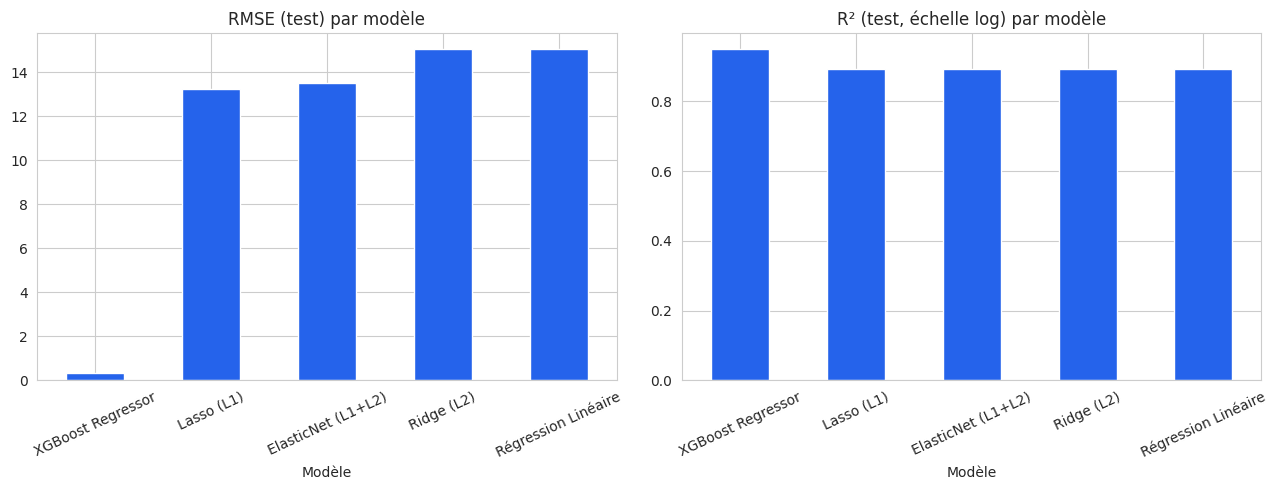

Meilleur modèle : XGBoost Regressor


0

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

reg_v2_results_df.set_index("Modèle")["RMSE (test)"].plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("RMSE (test) par modèle")
axes[0].tick_params(axis="x", rotation=25)

reg_v2_results_df.set_index("Modèle")["R² (test, log)"].plot(kind="bar", ax=axes[1], color="#2563eb")
axes[1].set_title("R² (test, échelle log) par modèle")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

best_reg_v2_name = reg_v2_results_df.iloc[0]["Modèle"]
print(f"Meilleur modèle : {best_reg_v2_name}")
plt.close('all')

import gc as _gc; _gc.collect()

### 17.6.5 Analyse résiduelle du meilleur modèle

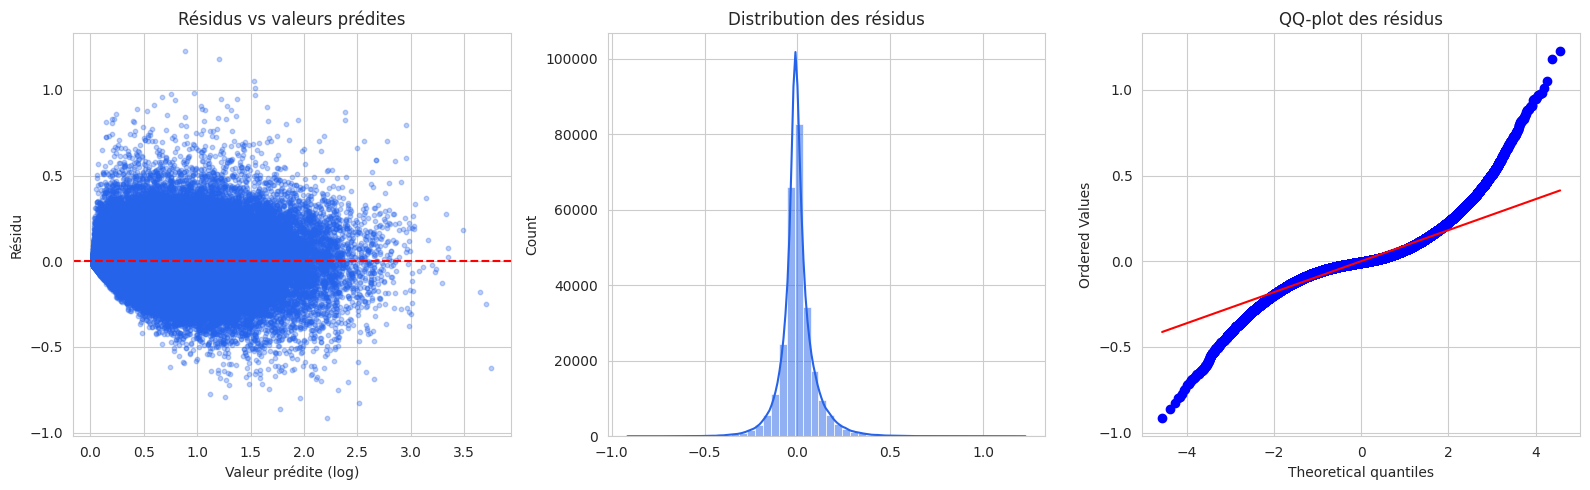

6038

In [19]:
best_model_v2, best_pred_v2, best_pred_log_v2 = fitted_reg_v2[best_reg_v2_name]
residuals = yte_reg2.values - best_pred_log_v2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(best_pred_log_v2, residuals, alpha=0.3, s=10, color="#2563eb")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valeur prédite (log)")
axes[0].set_ylabel("Résidu")
axes[0].set_title("Résidus vs valeurs prédites")

sns.histplot(residuals, bins=50, ax=axes[1], color="#2563eb", kde=True)
axes[1].set_title("Distribution des résidus")

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot des résidus")

plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

##### **Interprétation des diagnostics des résidus**

###### **Résidus vs prédictions**

Un nuage de points aléatoire autour de zéro indique que les erreurs sont réparties de manière homogène (**homoscédasticité**), ce qui correspond à un bon comportement du modèle.

Une forme en entonnoir indique que la variance des erreurs augmente avec les valeurs prédites : le modèle devient alors moins précis pour les clients ayant des dépenses élevées.


###### **Distribution des résidus**

Une distribution des résidus proche d'une cloche centrée autour de 0 indique que les erreurs sont globalement équilibrées.

Une asymétrie peut révéler un biais du modèle, par exemple une tendance à sous-estimer ou surestimer certains profils de clients.


###### **QQ-plot**

Un alignement des points autour de la diagonale indique que les résidus suivent approximativement une loi normale.

Cette hypothèse est importante pour les modèles linéaires (**Régression Linéaire, Ridge, Lasso, ElasticNet**).

`Un écart important, notamment aux extrémités, montre la présence de valeurs atypiques ou de comportements complexes. Dans ce cas, un modèle de boosting comme **XGBoost**, qui ne dépend pas de cette hypothèse, peut être plus adapté.`


In [20]:
import gc

_to_free = ['Xtr_reg2', 'Xte_reg2', 'ytr_reg2', 'yte_reg2', 'fitted_reg_v2', 'X_full_reg', 'X_full_reg_scaled', 'X_skb', 'X_ols', 'model_ols', 'gs_dt', 'gs_rf', 'gs_svr', 'gs_rfr']
for _n in _to_free:
    if _n in globals():
        del globals()[_n]
plt.close('all')
gc.collect()
print("Mémoire intermédiaire libérée.")

import gc as _gc; _gc.collect()

Mémoire intermédiaire libérée.


0